# Auto-Encoding Variational Bayes (Variational Autoencoder)

Replication of Kingma and Welling (2013), *Auto-Encoding Variational Bayes*, ICLR 2014.

We implement a variational autoencoder with the reparameterization trick and train it on
MNIST by maximizing the evidence lower bound (reconstruction term plus a KL regularizer).
Using a 2-dimensional latent space lets us reproduce two signature figures from the paper:
reconstructions of held-out digits and a smooth generative manifold obtained by decoding a
grid of latent coordinates.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)
ZDIM = 2

In [2]:
train = tv.datasets.MNIST("../data", train=True,  download=True, transform=T.ToTensor())
test  = tv.datasets.MNIST("../data", train=False, download=True, transform=T.ToTensor())
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
print("train", len(train), "test", len(test))

train 60000 test 10000


In [3]:
class VAE(nn.Module):
    def __init__(self, z=ZDIM):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.mu  = nn.Linear(400, z)
        self.lv  = nn.Linear(400, z)          # log-variance
        self.fc2 = nn.Linear(z, 400)
        self.fc3 = nn.Linear(400, 784)
    def encode(self, x):
        h = F.relu(self.fc1(x)); return self.mu(h), self.lv(h)
    def reparam(self, mu, lv):
        std = torch.exp(0.5*lv); return mu + std*torch.randn_like(std)   # reparameterization trick
    def decode(self, z):
        return torch.sigmoid(self.fc3(F.relu(self.fc2(z))))
    def forward(self, x):
        mu, lv = self.encode(x.view(-1, 784))
        z = self.reparam(mu, lv)
        return self.decode(z), mu, lv

def elbo(recon, x, mu, lv):
    bce = F.binary_cross_entropy(recon, x.view(-1, 784), reduction="sum")
    kld = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())     # KL to standard normal
    return bce + kld

In [4]:
vae = VAE(); opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS = 12
for ep in range(EPOCHS):
    vae.train(); total = 0.0
    for x, _ in train_dl:
        opt.zero_grad(); recon, mu, lv = vae(x)
        loss = elbo(recon, x, mu, lv); loss.backward(); opt.step()
        total += loss.item()
    print(f"epoch {ep+1:2d}: avg ELBO loss/sample = {total/len(train):.2f}")

epoch  1: avg ELBO loss/sample = 187.32


epoch  2: avg ELBO loss/sample = 165.82


epoch  3: avg ELBO loss/sample = 161.90


epoch  4: avg ELBO loss/sample = 159.54


epoch  5: avg ELBO loss/sample = 157.88


...

epoch  8: avg ELBO loss/sample = 154.66


epoch  9: avg ELBO loss/sample = 153.85


epoch 10: avg ELBO loss/sample = 153.18


epoch 11: avg ELBO loss/sample = 152.53


epoch 12: avg ELBO loss/sample = 152.05


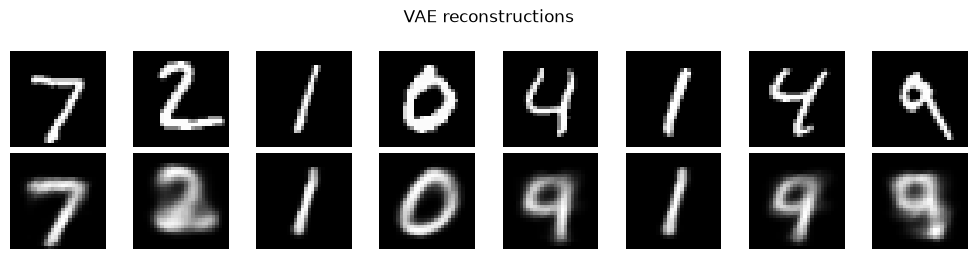

In [5]:
# Reconstructions of held-out test digits (top: input, bottom: reconstruction).
vae.eval()
xb, _ = next(iter(torch.utils.data.DataLoader(test, batch_size=8)))
with torch.no_grad():
    rb, _, _ = vae(xb)
fig, ax = plt.subplots(2, 8, figsize=(10, 2.6))
for i in range(8):
    ax[0, i].imshow(xb[i, 0], cmap="gray"); ax[0, i].axis("off")
    ax[1, i].imshow(rb[i].view(28, 28), cmap="gray"); ax[1, i].axis("off")
ax[0, 0].set_ylabel("in"); ax[1, 0].set_ylabel("out")
plt.suptitle("VAE reconstructions"); plt.tight_layout(); plt.show()

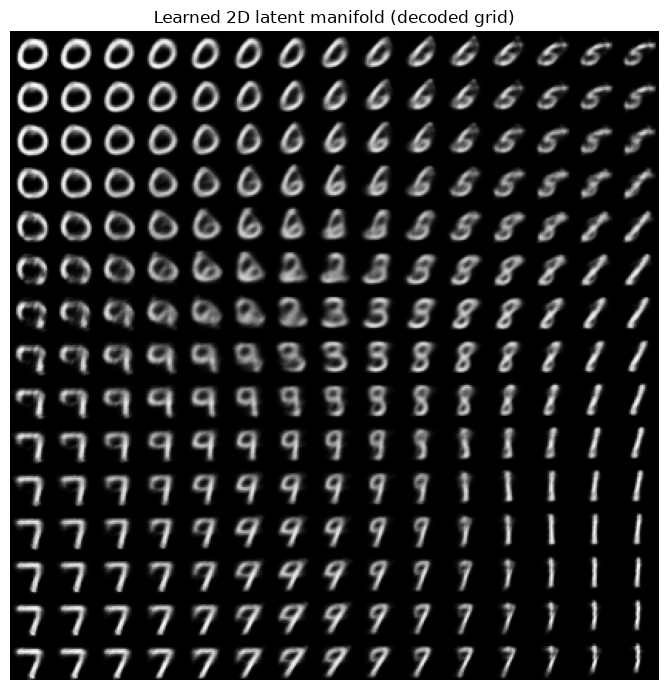

In [6]:
# Generative manifold: decode a grid of points in the 2D latent space.
import numpy as np
n = 15; grid = torch.linspace(-2.5, 2.5, n)
canvas = np.zeros((28*n, 28*n))
vae.eval()
with torch.no_grad():
    for i, yi in enumerate(grid):
        for j, xi in enumerate(grid):
            img = vae.decode(torch.tensor([[xi, yi]])).view(28, 28).numpy()
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img
plt.figure(figsize=(7, 7)); plt.imshow(canvas, cmap="gray"); plt.axis("off")
plt.title("Learned 2D latent manifold (decoded grid)"); plt.tight_layout(); plt.show()